In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("../data/raw/03_aum_by_fund_house.csv")

df.head()

,date,fund_house,aum_lakh_crore,aum_crore,num_schemes
0,2022-03-31,SBI Mutual Fund,6.05,605000,186
1,2022-03-31,ICICI Prudential MF,4.65,465000,216
2,2022-03-31,HDFC Mutual Fund,4.35,435000,195
3,2022-03-31,Nippon India MF,2.70,270000,177
4,2022-03-31,Kotak Mahindra MF,2.70,270000,168


In [4]:
# Check missing values
df.isnull().sum()

# Remove duplicates
df = df.drop_duplicates()

# Check data types
df.dtypes

# Save cleaned dataset
df.to_csv(
    "../data/processed/dataset3_cleaned.csv",
    index=False
)

In [8]:
df.shape

(90, 5)

In [9]:
df.columns

Index(['date', 'fund_house', 'aum_lakh_crore', 'aum_crore', 'num_schemes'], dtype='str')

In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 90 entries, 0 to 89
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   date            90 non-null     str    
 1   fund_house      90 non-null     str    
 2   aum_lakh_crore  90 non-null     float64
 3   aum_crore       90 non-null     int64  
 4   num_schemes     90 non-null     int64  
dtypes: float64(1), int64(2), str(2)
memory usage: 3.6 KB


In [11]:
df.describe()

,aum_lakh_crore,aum_crore,num_schemes
count,90.000000,9.000000e+01,90.000000
mean,4.352889,4.352889e+05,152.200000
std,2.734328,2.734328e+05,52.108832
min,1.050000,1.050000e+05,56.000000
25%,2.525000,2.525000e+05,95.000000
50%,3.450000,3.450000e+05,172.500000
75%,5.675000,5.675000e+05,195.000000
max,12.500000,1.250000e+06,216.000000


In [12]:
df["date"] = pd.to_datetime(df["date"])

df.dtypes

date              datetime64[us]
fund_house                   str
aum_lakh_crore           float64
aum_crore                  int64
num_schemes                int64
dtype: object

In [13]:
df.isnull().sum()

date              0
fund_house        0
aum_lakh_crore    0
aum_crore         0
num_schemes       0
dtype: int64

In [14]:
df.duplicated().sum()

np.int64(0)

In [15]:
df["fund_house"].nunique()

10

In [16]:
df["fund_house"].unique()

<StringArray>
[         'SBI Mutual Fund',      'ICICI Prudential MF',
         'HDFC Mutual Fund',          'Nippon India MF',
        'Kotak Mahindra MF', 'Aditya Birla Sun Life MF',
         'Axis Mutual Fund',          'UTI Mutual Fund',
           'Mirae Asset MF',          'DSP Mutual Fund']
Length: 10, dtype: str

In [17]:
df["date"].min(), df["date"].max()

(Timestamp('2022-03-31 00:00:00'), Timestamp('2025-12-31 00:00:00'))

In [18]:
latest_date = df["date"].max()

latest_df = df[df["date"] == latest_date]

latest_df

,date,fund_house,aum_lakh_crore,aum_crore,num_schemes
80,2025-12-31,SBI Mutual Fund,12.50,1250000,186
81,2025-12-31,ICICI Prudential MF,10.74,1074000,216
82,2025-12-31,HDFC Mutual Fund,9.30,930000,195
83,2025-12-31,Nippon India MF,7.00,700000,177
84,2025-12-31,Kotak Mahindra MF,5.80,580000,168
85,2025-12-31,Aditya Birla Sun Life MF,4.60,460000,199
86,2025-12-31,Axis Mutual Fund,3.50,350000,95
87,2025-12-31,UTI Mutual Fund,4.10,410000,142
88,2025-12-31,Mirae Asset MF,2.90,290000,56
89,2025-12-31,DSP Mutual Fund,2.30,230000,88


In [19]:
latest_df.sort_values(
    "aum_crore",
    ascending=False
)

,date,fund_house,aum_lakh_crore,aum_crore,num_schemes
80,2025-12-31,SBI Mutual Fund,12.50,1250000,186
81,2025-12-31,ICICI Prudential MF,10.74,1074000,216
82,2025-12-31,HDFC Mutual Fund,9.30,930000,195
83,2025-12-31,Nippon India MF,7.00,700000,177
84,2025-12-31,Kotak Mahindra MF,5.80,580000,168
85,2025-12-31,Aditya Birla Sun Life MF,4.60,460000,199
87,2025-12-31,UTI Mutual Fund,4.10,410000,142
86,2025-12-31,Axis Mutual Fund,3.50,350000,95
88,2025-12-31,Mirae Asset MF,2.90,290000,56
89,2025-12-31,DSP Mutual Fund,2.30,230000,88


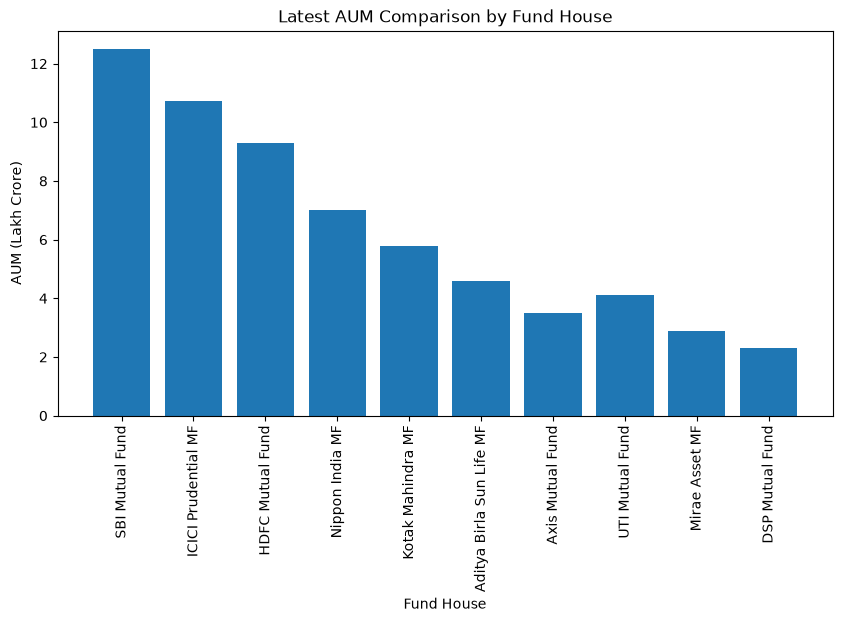

In [20]:
plt.figure(figsize=(10,5))

plt.bar(
    latest_df["fund_house"],
    latest_df["aum_lakh_crore"]
)

plt.title("Latest AUM Comparison by Fund House")
plt.xlabel("Fund House")
plt.ylabel("AUM (Lakh Crore)")

plt.xticks(rotation=90)

plt.show()

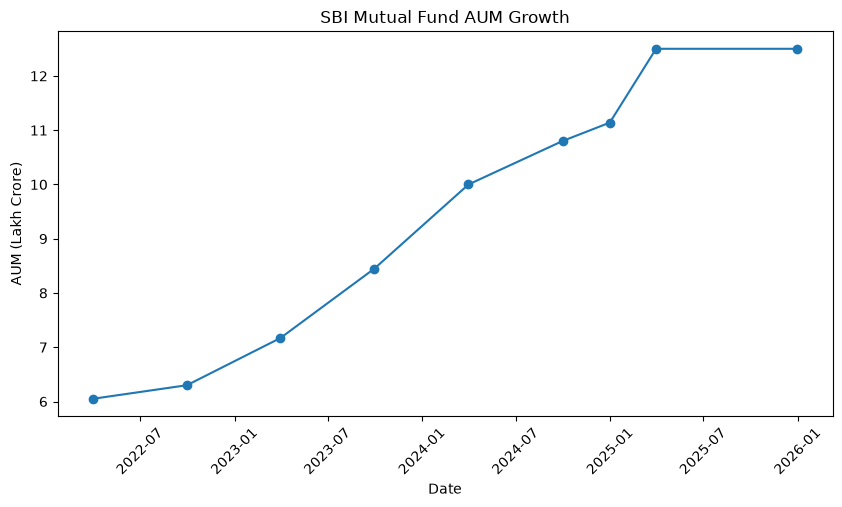

In [21]:
sbi = df[df["fund_house"]=="SBI Mutual Fund"]

plt.figure(figsize=(10,5))

plt.plot(
    sbi["date"],
    sbi["aum_lakh_crore"],
    marker="o"
)

plt.title("SBI Mutual Fund AUM Growth")
plt.xlabel("Date")
plt.ylabel("AUM (Lakh Crore)")

plt.xticks(rotation=45)

plt.show()

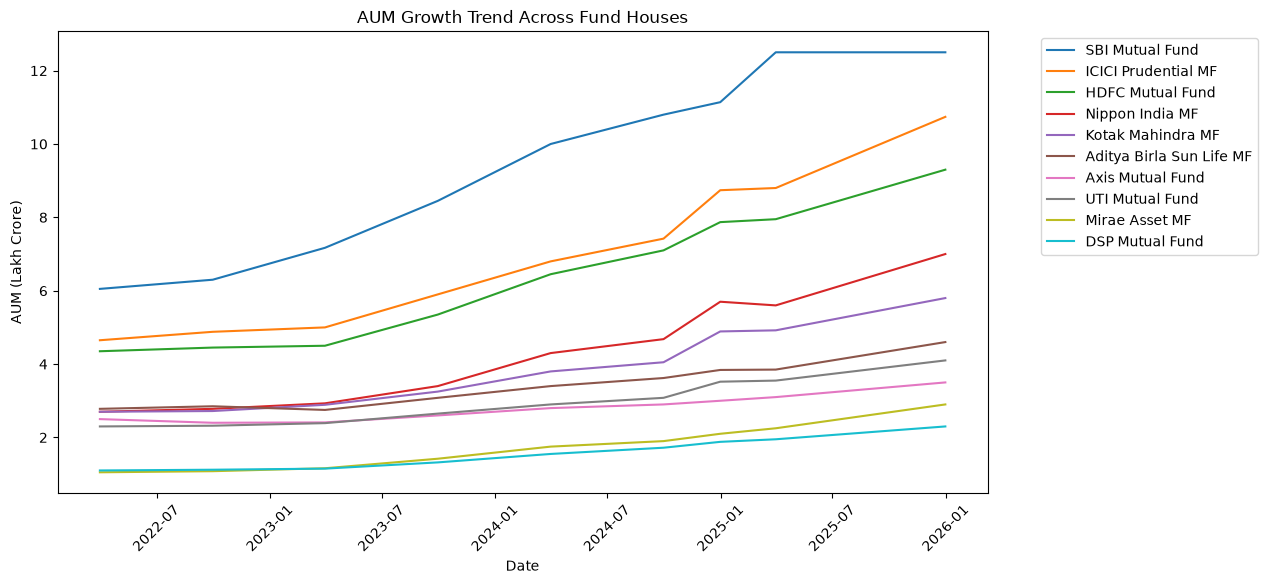

In [23]:
plt.figure(figsize=(12,6))

for fund in df["fund_house"].unique():
    
    temp = df[df["fund_house"] == fund]
    
    plt.plot(
        temp["date"],
        temp["aum_lakh_crore"],
        label=fund
    )

plt.title("AUM Growth Trend Across Fund Houses")
plt.xlabel("Date")
plt.ylabel("AUM (Lakh Crore)")

plt.legend(
    bbox_to_anchor=(1.05,1),
    loc="upper left"
)

plt.xticks(rotation=45)

plt.show()

In [24]:
latest_df.sort_values(
    "num_schemes",
    ascending=False
)[["fund_house","num_schemes"]]

,fund_house,num_schemes
81,ICICI Prudential MF,216
85,Aditya Birla Sun Life MF,199
82,HDFC Mutual Fund,195
80,SBI Mutual Fund,186
83,Nippon India MF,177
84,Kotak Mahindra MF,168
87,UTI Mutual Fund,142
86,Axis Mutual Fund,95
89,DSP Mutual Fund,88
88,Mirae Asset MF,56


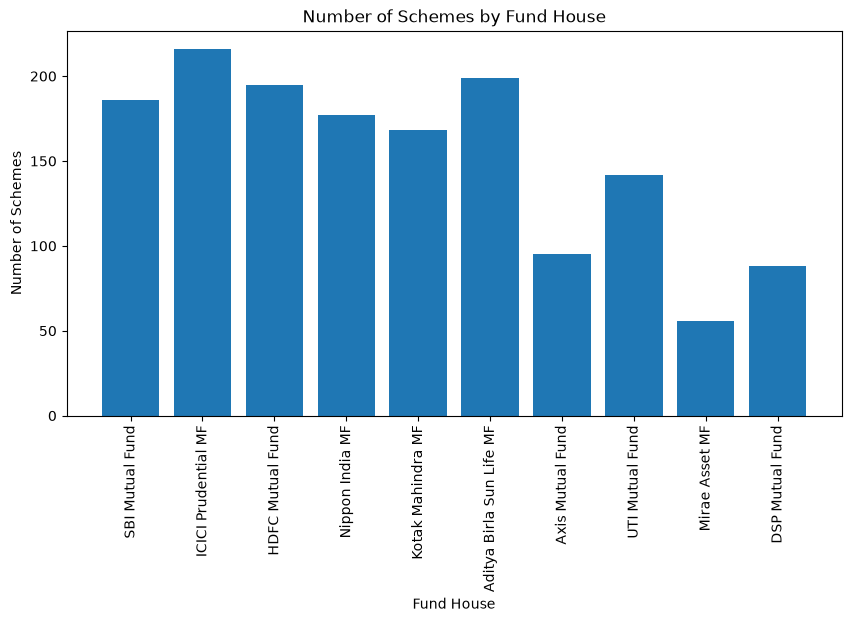

In [25]:
plt.figure(figsize=(10,5))

plt.bar(
    latest_df["fund_house"],
    latest_df["num_schemes"]
)

plt.title("Number of Schemes by Fund House")
plt.xlabel("Fund House")
plt.ylabel("Number of Schemes")

plt.xticks(rotation=90)

plt.show()

# Insights from Fund House AUM Dataset

## Dataset Overview
- Dataset contains Assets Under Management (AUM) information of mutual fund houses.
- Total fund houses analyzed: 10.
- Data period covers March 2022 to December 2025.

## Data Quality
- Date column was converted into datetime format.
- No missing values were found.
- No duplicate records were identified.

## AUM Analysis
- Fund houses showed continuous growth in Assets Under Management over the analysis period.
- SBI Mutual Fund maintained the highest AUM among the analyzed fund houses.
- Large fund houses contributed significantly to the overall mutual fund market.

## Scheme Analysis
- Fund houses manage different numbers of mutual fund schemes.
- Scheme count indicates the product diversity offered by each fund house.

## Key Observation
The increasing AUM trend reflects growth in investor participation and expansion of the mutual fund industry.